# testing CNN model

### import required packages

In [2]:
import numpy as np
import torch
import torch.nn as nn
import cv2
import matplotlib.pyplot as plt

### select the device

In [3]:
device = ""
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"using device = {device}")

using device = cuda


### define the model

In [4]:

model = nn.Sequential(

    # add the convolution2d layer
    # in_channels = 1: at a time only one image will be fed to the CNN for processing
    # out_channels = 16: number of features to be extracted (the CNN will create 16 number of kernels, each one of 3x3 size)
    # kernel_size = 3: we will be using a kernel of 3x3 size
    # padding = 1: add the padding on all the borders 
    # stride = 1: move to the right side by one column and down by one row
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1, stride=1),

    # configure ReLu activation function
    nn.ReLU(),

    # add max pooling layer
    nn.MaxPool2d(kernel_size=2, stride=2),

    # add one more convolution layer
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1, stride=1),

    # configure ReLu activation function
    nn.ReLU(),

    # add max pooling layer
    nn.MaxPool2d(kernel_size=2, stride=2),
    
    # add the flatten layer
    nn.Flatten(),

    # add the hidden layer with 128 neurons
    nn.Linear(in_features=32*7*7, out_features=128),

    # add ReLu on the hidden layer
    nn.ReLU(),

    # add the output layer
    # since there are 10 digits the output layer will have 10 neurons
    nn.Linear(in_features=128, out_features=10)
)

# move the model to device
model = model.to(device)

In [6]:
# load the parameters into the model
model.load_state_dict(torch.load('./mnist_model.pth'))

<All keys matched successfully>

In [7]:
# disable learning parameters by enabling the eval mode
model.eval()

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

### load the image

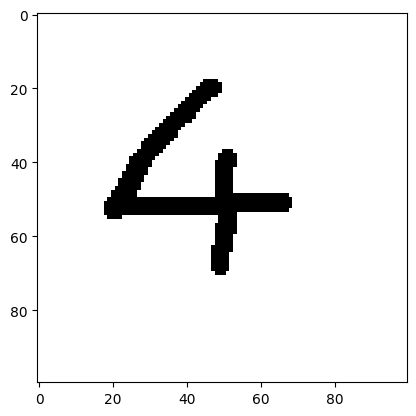

In [8]:
image = cv2.imread('./test.png')
plt.imshow(image)

### pre-process the image

True

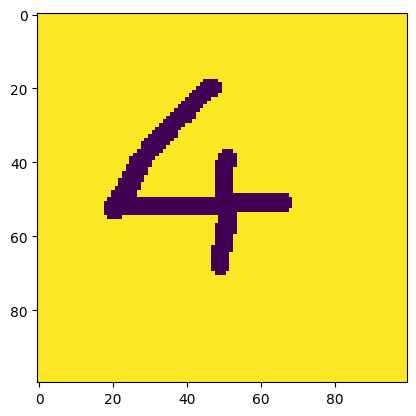

In [9]:
# conver the image to grayscale
image_grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_grayscale)
cv2.imwrite("test_grayscale.png", image_grayscale)

True

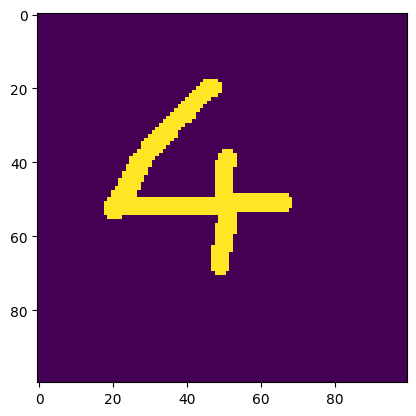

In [10]:
# convert the image to binary 
return_value, binary_image = cv2.threshold(image_grayscale, 150, 255, cv2.THRESH_BINARY_INV)
plt.imshow(binary_image)
cv2.imwrite("test_binary.png", binary_image)

### extract only the digit from the image

In [11]:
# find the location of the digit in the image
points = cv2.findNonZero(binary_image)
print(points)

[[45 18]
 [46 18]
 [47 18]
 ...
 [48 70]
 [49 70]
 [50 70]]


In [12]:
# find the bounding rect from the image
x, y, w, h = cv2.boundingRect(points)

# extract the digit 
digit = binary_image[y:y+h, x:x+w]
print(digit)

cv2.imwrite('test_digit.png', digit)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


True

### conver the image to 28x28 moving the digit to the center

In [13]:
# get the size
size = max(w, h)

In [14]:
# make a square of sizexsize
square = np.zeros((size, size), dtype=np.uint8)

# find the x and y offset 
x_offset = (size - w) // 2
y_offset = (size - h) // 2

In [15]:
# put the digit in the center part of the image
square[y_offset: y_offset + h, x_offset: x_offset + w] = digit

In [16]:
square

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(53, 53), dtype=uint8)

True

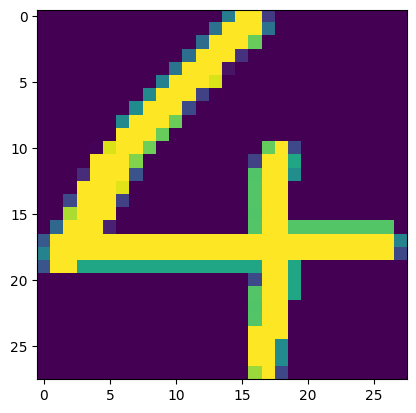

In [17]:
# resize the image to match model's requirement 28x28
image_resized = cv2.resize(square, (28, 28))
plt.imshow(image_resized)
cv2.imwrite("test_final.png", image_resized)

### get the class by passing the image to the model

In [18]:
from torchvision import transforms

transformer = transforms.ToTensor()

# convert the image to the tensor
image = transformer(image_resized)
image.shape

torch.Size([1, 28, 28])

In [19]:
# unsqueeze the image
image = image.unsqueeze(0)
image.shape

torch.Size([1, 1, 28, 28])

In [20]:
# move the image to device
image = image.to(device)

In [21]:
with torch.no_grad():
    # pass the image to the model
    output = model(image)
    print(f"output = {output}")

    # find the actual class
    prediction = torch.argmax(output, dim=1)
    print(f"final class = {prediction}")

output = tensor([[-8.1685, -3.6341, -1.5379, -8.4913,  9.8437, -6.3605,  2.3175, -4.4611,
         -9.1058, -1.9384]], device='cuda:0')
final class = tensor([4], device='cuda:0')
